In [ ]:
# def gen(N, x_min, x_max, y_min, y_max, fi1=0, fi2=0, fi3=0, strait_ratio=0.5) #strait_ratio = (0,1) направление прямо или нет
# #float разделить значения с округлением


# def gen_shift( data,  shift = 0.01, y2):
#     data[y2]= data[y2] + shift
#     return data



In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def gen(N, x_min=0, x_max=10, y_min=0, y_max=10, fi1=0, fi2=0, fi3=0, straight_ratio=0.5, rand_seed=40, decimals=None):

    """
    Генерирует данные в формате [x1, y1, x2, y2, x3, y3] для N точек.
    x_min, x_max, y_min, y_max - пределы значений
    straight_ratio определяет процент прямых линий
    rand_seed задаёт сид для локального генератора случайных чисел
    decimals задаёт округление значений до указанного знака

    """

    rng = np.random.default_rng(rand_seed)

    N_straight = int(N * straight_ratio)
    N_avg = N - N_straight

    # прямые линии
    x_strait = rng.uniform(x_min, x_max, N_straight)
    y_strait = rng.uniform(y_min, y_max, N_straight)
    strait_data = np.column_stack([x_strait, y_strait, x_strait, y_strait, x_strait, y_strait])

    # линии под углом
    x1 = rng.uniform(x_min, x_max, N_avg)
    y1 = rng.uniform(y_min, y_max, N_avg)
    x3 = rng.uniform(x_min, x_max, N_avg)
    y3 = rng.uniform(y_min, y_max, N_avg)

    x2 = (x1 + x3) / 2
    y2 = (y1 + y3) / 2
    avg_data = np.column_stack([x1, y1, x2, y2, x3, y3])

    # Объединение
    if N_straight == 0:
        data = avg_data
    elif N_avg == 0:
        data = strait_data
    else:
        data = np.vstack([strait_data, avg_data])

    # Округление
    if decimals is not None:
        data = np.round(data, decimals=decimals)

    return data


def gen_shift(data, shift=0.01, loc=3):
    """создаёт сдвиг указанного размера на указанной позиции"""
    data = data.copy()
    data[:, loc] += shift
    return data


def plot_dist(data, bins=30, figsize=(12, 4)):
    y1, y2, y3 = data[:, 1], data[:, 3], data[:, 5]

    fig, axs = plt.subplots(1, 3, figsize=figsize, sharey=True)
    colors = ['skyblue', 'lightgreen', 'salmon']
    labels = ['y1', 'y2', 'y3']

    for ax, y, color, label in zip(axs, [y1, y2, y3], colors, labels):
        ax.hist(y, bins=bins, color=color, edgecolor='black', alpha=0.8)
        ax.set_xlabel(label)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_title(f'Распределение {label}')

    plt.tight_layout()
    plt.show()

In [ ]:
np.set_printoptions(precision=8, suppress=True, floatmode='fixed')

In [ ]:
data = gen(10000, 0, 10, 0, 10, straight_ratio=1, rand_seed=42, decimals=8)
print("До сдвига:\n", data)

data_shifted = gen_shift(data, shift=0.1, loc=3)
print("\nПосле сдвига:\n", data_shifted)

До сдвига:
 [[7.73956049 7.20728387 7.73956049 7.20728387 7.73956049 7.20728387]
 [4.38878440 7.11237761 4.38878440 7.11237761 4.38878440 7.11237761]
 [8.58597920 2.02695031 8.58597920 2.02695031 8.58597920 2.02695031]
 ...
 [1.65346968 8.47131068 1.65346968 8.47131068 1.65346968 8.47131068]
 [3.73410398 6.70803244 3.73410398 6.70803244 3.73410398 6.70803244]
 [4.80907773 1.41260045 4.80907773 1.41260045 4.80907773 1.41260045]]

После сдвига:
 [[7.73956049 7.20728387 7.73956049 7.30728387 7.73956049 7.20728387]
 [4.38878440 7.11237761 4.38878440 7.21237761 4.38878440 7.11237761]
 [8.58597920 2.02695031 8.58597920 2.12695031 8.58597920 2.02695031]
 ...
 [1.65346968 8.47131068 1.65346968 8.57131068 1.65346968 8.47131068]
 [3.73410398 6.70803244 3.73410398 6.80803244 3.73410398 6.70803244]
 [4.80907773 1.41260045 4.80907773 1.51260045 4.80907773 1.41260045]]


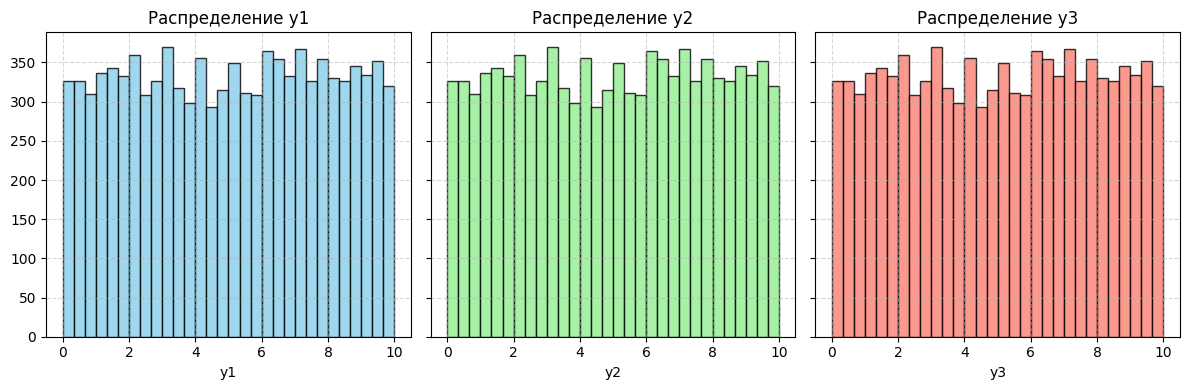

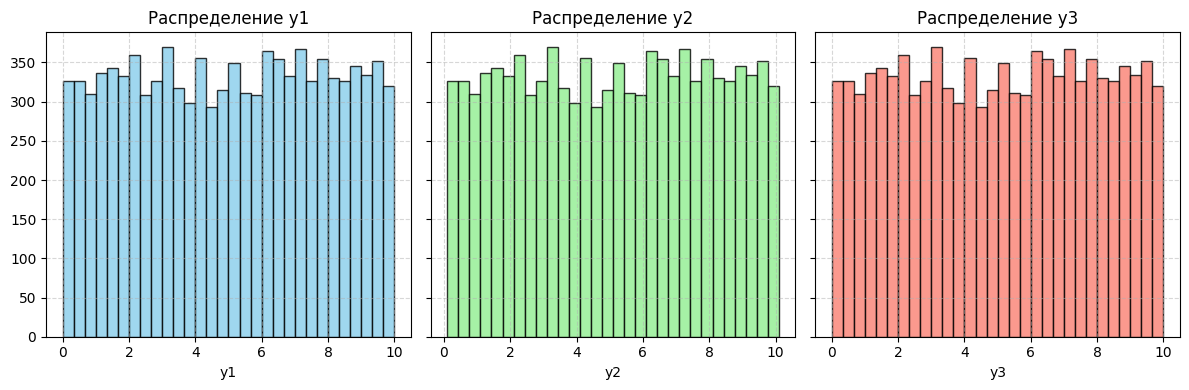

In [ ]:
plot_dist(data)
plot_dist(data_shifted)

In [ ]:
data2 = gen(10000, 0, 10, 0, 10, straight_ratio=0.5, rand_seed=28, decimals=8)
print("До сдвига:\n", data2)

data_shifted_2 = gen_shift(data2.copy(), shift=2, loc=3)
print("\nПосле сдвига:\n", data_shifted_2)

До сдвига:
 [[8.51833936 4.36194842 8.51833936 4.36194842 8.51833936 4.36194842]
 [8.84892954 3.84866468 8.84892954 3.84866468 8.84892954 3.84866468]
 [7.65708527 1.30158475 7.65708527 1.30158475 7.65708527 1.30158475]
 ...
 [7.75785131 7.96953990 8.56783915 4.83547700 9.37782698 1.70141410]
 [5.60198462 8.51752838 3.92379126 7.60244717 2.24559791 6.68736596]
 [6.28798981 5.99425087 5.75923640 5.24345548 5.23048298 4.49266008]]

После сдвига:
 [[8.51833936 4.36194842 8.51833936 6.36194842 8.51833936 4.36194842]
 [8.84892954 3.84866468 8.84892954 5.84866468 8.84892954 3.84866468]
 [7.65708527 1.30158475 7.65708527 3.30158475 7.65708527 1.30158475]
 ...
 [7.75785131 7.96953990 8.56783915 6.83547700 9.37782698 1.70141410]
 [5.60198462 8.51752838 3.92379126 9.60244717 2.24559791 6.68736596]
 [6.28798981 5.99425087 5.75923640 7.24345548 5.23048298 4.49266008]]


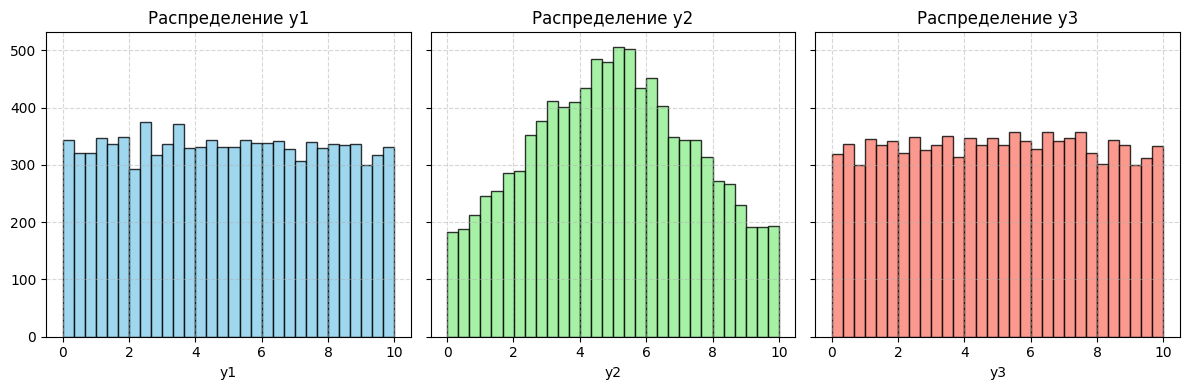

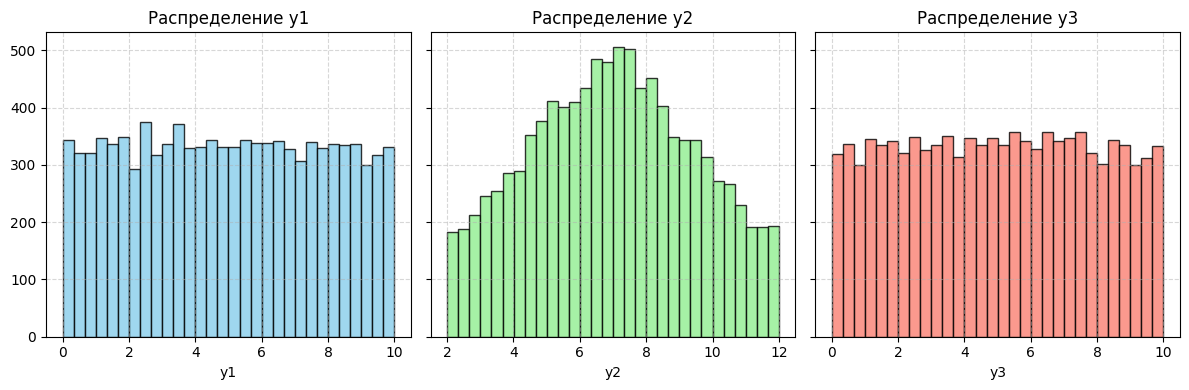

In [ ]:
plot_dist(data2)
plot_dist(data_shifted_2)